# Notebook 38 — qualification gate, mechanism attribution, and the sealed-bank spend decision

**Plan of record:** `docs/NOTEBOOK_38_CLAUDE_PLAN.md` · **Module:** `sleep_sbi.figure10_notebook38_claude`
· **Tests:** `S4_sbi/tests/test_notebook38_claude.py` · **Kernel:** `neurolib`

Notebook 37 handed over `CONDITIONAL_GO` with Branch 1 (reuse the existing estimator) subject to a
global qualification gate. This notebook is that gate.

It starts from a measurement, not a plan. Notebook 36 persisted support-safe marginal and joint
ranks for **1024 / 1023 cases × 6 estimators** in
`artifacts/notebook_36/samples/phase3/{track}/support_safe_ranks_{track}.npz`, plus E0 in
`samples/phase4/`. That is every input a Development battery needs. Recomputing the verdict from
those ranks takes seconds — so the question this notebook has to answer first is not *what is the
verdict* but **what new computation could still change it**.

| | Question | Status going in |
|---|---|---|
| **Q1** | Is the estimator qualified under the inherited diagnostic battery? | Determined by artifacts on disk — recompute and *prove* the reproduction |
| **Q2** | Which statistics are even admissible as evidence? | Open, and it changes the answer to Q1 |
| **Q3** | *Why* does it fail, and does anything survive? | Open, answerable at zero simulation cost |
| **Q4** | Spend or preserve the one unspent pre-registration asset? | Open — this is the decision that matters for NB39–41 |

**Hard locks.** No training. No new simulations except the bounded Phase 6 audit (2 × 128 cases).
`torch` / `sbi` are imported *only inside Phase 6*; phases 0–5 and 7 are structurally incapable of
sampling. The sealed bank is metadata-only throughout — the default execution path can never open
it. `test_notebook38_claude.py` asserts all of this.

In [1]:
import importlib.util
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 60)

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "S4_sbi").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC = PROJECT_ROOT / "S4_sbi" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

_spec = importlib.util.spec_from_file_location(
    "figure10_notebook38_claude",
    SRC / "sleep_sbi" / "figure10_notebook38_claude.py",
)
nb38 = importlib.util.module_from_spec(_spec)
sys.modules[_spec.name] = nb38
_spec.loader.exec_module(nb38)

print("project root :", PROJECT_ROOT)
print("torch imported at module level :", "torch" in sys.modules)
env = nb38.environment_report()
print("python", env["python"], "| git", env["git"]["head"][:10], "| dirty", env["git"]["dirty"])

project root : D:\Year3_Mao_Projects\sleep_loop
torch imported at module level : False


python 3.10.20 | git 14a334bb0a | dirty True


---

## Phase 0a — the rule that governs every later cell

Each registered job declares `could_change`: the verdict cells it could move. The dispatcher
refuses to run a job with an empty declaration, and `samples_posteriors` is declared explicitly
rather than inferred from a runtime guess.

This is the mechanism that keeps the notebook from spending hours reproducing a foregone
conclusion. Two jobs the alternative plan budgets ~14 h for are absent from this table, and their
absence is a decision recorded in the admissibility ledger, not an omission.

In [2]:
manifest = nb38.job_manifest()
print(f"{len(manifest)} registered jobs; "
      f"{int(manifest['samples_posteriors'].sum())} of them sample posteriors")
manifest

13 registered jobs; 1 of them sample posteriors


,job,phase,could_change,estimated_seconds,samples_posteriors
0,generation_and_provenance_manifest,0,integrity_status,3.0,False
1,pairing_audit,0,integrity_status; mechanism_attribution,10.0,False
2,prior_proposal_situation,0,situation_A_or_B; final_qualification_status,5.0,False
3,dev_scorecard,1,development_status; qualification_ledger; mech...,15.0,False
4,nb36_reproduction_check,1,integrity_status,20.0,False
5,admissibility_ledger,2,admissible_evidence_set; final_qualification_s...,5.0,False
6,lc2st_claim_ceiling,2,claim_ceiling,2.0,False
7,selection_adjusted_joint_test,2,E2_ref_joint_evidence; final_qualification_status,120.0,False
8,mechanism_attribution,3,mechanism_attribution; nb39_handoff_mode,30.0,False
9,qualification_ledger,4,qualification_ledger; claim_ceiling,40.0,False


---

## Phase 0 — provenance, the p ≡ q fingerprint, and the cross-track alignment trap

Two separate artifacts, deliberately not merged:

* **`statistical_spec_fingerprint`** — probability-law fields only (names, order, dimension,
  bounds, `independent_uniform_box`, factorization, affine map, support convention,
  normalization) → canonical sorted-key JSON → SHA-256. This is the *sole* p = q criterion.
* **`generation_and_provenance_manifest`** — Sobol seeds, `qmc.scale`, schema hash, file hashes.
  Integrity and design fidelity only. Two files with different SHA-256 can encode the same
  distribution; a matching seed does not make two different boxes equal.

`p` is read from the preregistration contract block; `q` from `theta_lower_{track}` /
`theta_upper_{track}` in the frozen training split. Different files, different hashes — the
question is whether they encode the same law.

In [3]:
situation = nb38.prior_proposal_situation()
display(pd.DataFrame(situation["table"]))
for track, verdict in situation["per_track"].items():
    print(f"{track}: {verdict}")
print()
print("importance weighting permitted:", situation["importance_weighting_permitted"])
print(situation["note"])

,track,p_fingerprint,q_fingerprint,equal,verdict
0,7d,5b93f89d1b08024895acd42155044db1a5ebbeac5cc6c9...,5b93f89d1b08024895acd42155044db1a5ebbeac5cc6c9...,True,SITUATION_A_NO_PRIOR_PROPOSAL_CORRECTION_REQUIRED
1,8d,f6af4c065ef315974ed35ed8de83e7e1be1793eb1e6811...,f6af4c065ef315974ed35ed8de83e7e1be1793eb1e6811...,True,SITUATION_A_NO_PRIOR_PROPOSAL_CORRECTION_REQUIRED


7d: SITUATION_A_NO_PRIOR_PROPOSAL_CORRECTION_REQUIRED
8d: SITUATION_A_NO_PRIOR_PROPOSAL_CORRECTION_REQUIRED

importance weighting permitted: False
Situation A forbids importance weighting: if p == q there is nothing to correct, and a correction would inject variance for no bias reduction. Differing source-file SHA-256 values do not imply p != q.


### The alignment trap

The 7D and 8D designs are paired by construction. But 8D dropped case 45 for `EXTREME_LEAKAGE`, so
the persisted arrays are 1024 vs 1023 rows. Every cross-track statement in this notebook joins on
**case id**; the cell below shows what a positional join would have compared instead.

In [4]:
pairing = nb38.pairing_audit()
print(f"7D rows: {pairing['n_7d']}   8D rows: {pairing['n_8d']}   common: {pairing['n_common']}")
print(f"8D excluded case ids: {pairing['excluded_8d']}")
print()
print(f"case-id keyed  : max |theta_7d - theta_8d[:, :7]| = "
      f"{pairing['max_theta_deviation_case_id_keyed']:.3e}  -> paired = {pairing['paired_on_case_id']}")
print(f"positional     : max |theta_7d - theta_8d[:, :7]| = "
      f"{pairing['max_theta_deviation_positional']:.3e}  over "
      f"{pairing['positionally_misaligned_rows']} misaligned rows")
print()
print(pairing["reporting_rule"])

7D rows: 1024   8D rows: 1023   common: 1023
8D excluded case ids: [45]

case-id keyed  : max |theta_7d - theta_8d[:, :7]| = 0.000e+00  -> paired = True
positional     : max |theta_7d - theta_8d[:, :7]| = 9.701e-01  over 978 misaligned rows

Report paired_designs plus per-track simulation counts. Never 7D + 8D = 65536.


---

## Phase 1 — the free verdict, and the reproduction that licenses it

Everything below comes from Notebook 36's persisted ranks. Nothing is re-sampled.

The integrity claim is the point of the phase: every marginal KS p-value, every joint KS p-value
and every Holm flag recomputed here is checked against Notebook 36's **published CSVs**. That is a
stronger reproducibility claim than re-running the sampler with fresh seeds, which would produce
numbers that agree with nothing. If this check fails, the reused artifacts are stale and the
verdict below is void.

In [5]:
check = nb38.nb36_reproduction_check()
summary = check.groupby("statistic")["agrees"].agg(["size", "sum"])
summary.columns = ["compared", "agree"]
display(summary)
disagreements = check[~check["agrees"]]
print(f"disagreements: {len(disagreements)}")
if len(disagreements):
    display(disagreements.head(20))
else:
    print("Phase 1 reproduces Notebook 36 exactly. The verdict below is licensed.")

,compared,agree
statistic,,
holm_clear_issue,90,90
joint_ks_pvalue,12,12
marginal_ks_pvalue,90,90


disagreements: 0
Phase 1 reproduces Notebook 36 exactly. The verdict below is licensed.


In [6]:
scorecard = nb38.dev_scorecard()
view = scorecard[[
    "track", "estimator", "is_E2_ref", "n_cases", "joint_ks_pvalue", "J",
    "n_holm_clear", "holm_clear_parameters", "S", "C", "development_status",
]].copy()
view["joint_ks_pvalue"] = view["joint_ks_pvalue"].map(lambda v: f"{v:.4g}")
display(view)

n_sfail = int((scorecard["S"] == "S_fail").sum())
print(f"\nS_fail fires on {n_sfail} of {len(scorecard)} estimator x track cells.")
print("Elapsed cost of establishing this: seconds. No posterior was re-sampled.")

,track,estimator,is_E2_ref,n_cases,joint_ks_pvalue,J,n_holm_clear,holm_clear_parameters,S,C,development_status
0,7d,ensemble,False,1024,2.686e-39,J_fail,3,mue; mui; tauA,S_fail,C_fail,DEV_FAIL
1,7d,member_1,False,1024,0.03241,J_mid,5,mue; mui; tauA; g_LK; c_th2ctx,S_fail,C_lim,DEV_FAIL
2,7d,member_2,False,1024,0.2552,J_pass,3,mue; mui; tauA,S_fail,C_fail,DEV_FAIL
3,7d,member_3,False,1024,0.1523,J_pass,6,mue; mui; b; tauA; g_LK; c_th2ctx,S_fail,C_fail,DEV_FAIL
4,7d,member_4,True,1024,0.7121,J_pass,3,mue; mui; tauA,S_fail,C_fail,DEV_FAIL
5,7d,member_5,False,1024,0.4602,J_pass,6,mue; mui; b; tauA; g_LK; c_th2ctx,S_fail,C_fail,DEV_FAIL
6,7d,E0,False,1024,7.029e-39,J_fail,3,mue; mui; tauA,S_fail,C_fail,DEV_FAIL
7,8d,ensemble,False,1023,5.531e-44,J_fail,3,mue; mui; tauA,S_fail,C_fail,DEV_FAIL
8,8d,member_1,False,1023,0.05374,J_pass,4,mue; mui; tauA; c_th2ctx,S_fail,C_fail,DEV_FAIL
9,8d,member_2,False,1023,0.001862,J_fail,4,mue; mui; tauA; c_th2ctx,S_fail,C_fail,DEV_FAIL



S_fail fires on 14 of 14 estimator x track cells.
Elapsed cost of establishing this: seconds. No posterior was re-sampled.


`S_fail` on every cell, including the **E0 negative control**. Under any Development rule that
contains a marginal-SBC atom — the alternative plan's included — this is `DEV_FAIL` on both tracks,
sealed eligibility `DENIED`, and the ~14 h battery that would have produced it could not have
produced anything else.

Note also `8d:member_2` at joint p = 0.0019 versus `7d:member_4` at 0.712. The members are not
interchangeable, which matters for the next phase.

---

## Phase 2 — admissibility, adjudicated before anything is read as evidence

Notebook 36's `phase4_aggregation_arms.csv` labels the E2 arm verbatim: *"best single member by
joint KS (regression reference)"*. So **E2_ref ≡ argmax over five members of the joint-KS p-value,
computed on `powered_1024`** — the same dataset a Development joint-KS gate would test it on.

Testing the maximum at α = 0.05 on the data used to select it has close to no power. Disclosing the
provenance and then gating on it anyway does not repair that. Here the statistic is barred from the
gate and replaced with a selection-aware one.

Second, a rule that cannot be pre-registered: coverage@90 with Wilson intervals is not among the
original figure-10 PASS atoms. Proposing it as a gate *after* the ranks are visible is post-hoc
choice of a decision rule, and a `protocol_lock` written now cannot restore pre-registration over
data Notebook 36 already published. It is reported, and it does not gate.

In [7]:
ledger = nb38.admissibility_ledger()
display(ledger)
print("may enter the gate:",
      sorted(set(ledger[ledger.may_enter_gate]["diagnostic"])))

,diagnostic,scope,verdict,may_enter_gate,reason
0,joint_ks,7d:member_4 (E2_ref),INADMISSIBLE_SELECTION,False,E2_ref == argmax joint-KS p over 5 members on ...
1,joint_ks,"7d:{ensemble, member_1, member_2, member_3, me...",ADMISSIBLE,True,Not selected on; joint KS is an inherited NB33...
2,joint_ks_selection_adjusted,7d:member_4 (E2_ref),ADMISSIBLE,True,Max-of-K null built by case bootstrap over the...
3,joint_ks,8d:member_3 (E2_ref),INADMISSIBLE_SELECTION,False,E2_ref == argmax joint-KS p over 5 members on ...
4,joint_ks,"8d:{ensemble, member_1, member_2, member_4, me...",ADMISSIBLE,True,Not selected on; joint KS is an inherited NB33...
5,joint_ks_selection_adjusted,8d:member_3 (E2_ref),ADMISSIBLE,True,Max-of-K null built by case bootstrap over the...
6,marginal_sbc_ks_holm,"all estimators, both tracks",ADMISSIBLE,True,"Inherited NB33/NB34 PASS atom, unchanged. E2_r..."
7,coverage_90_wilson,as a gate atom,INADMISSIBLE_POST_HOC,False,Not among the original figure10 PASS atoms. Pr...
8,coverage_90_wilson,as description,DESCRIPTIVE,False,Reported per parameter with Wilson CI and NB35...
9,lc2st,both tracks,CLAIM_CEILING_ONLY,False,"Local, observation-conditional test at one fro..."


may enter the gate: ['joint_ks', 'joint_ks_selection_adjusted', 'marginal_sbc_ks_holm']


### The selection-adjusted joint test

The null must satisfy two conditions the naive test does not. **(i)** H0 has to actually hold in
the reference distribution, so each member's rank column is passed through an empirical-copula
transform — replaced by its own within-column ranks, forcing exactly uniform margins while leaving
the cross-member association untouched. **(ii)** The five members share θ and share cases, so their
statistics are dependent; the case bootstrap resamples whole rows and carries that dependence into
the null. An independence correction such as `1 − p^K` assumes it away, and is shown only as a
contrast.

Upper-tailed in D: a large KS distance is a bad fit, so the adjusted p is `P(min_k D_k ≥ observed)`.

In [8]:
selection = {track: nb38.selection_adjusted_joint_test(track) for track in nb38.TRACKS}
rows = []
for track, result in selection.items():
    rows.append({
        "track": track,
        "E2_ref": result["E2_ref"],
        "is argmax?": result["E2_ref_is_argmax_p"],
        "naive p (display only)": round(result["naive_joint_p_of_E2_ref"], 4),
        "selection-adjusted p": round(result["selection_adjusted_p"], 4),
        "if independent (wrong)": round(result["p_if_members_were_independent_do_not_use"], 4),
        "observed min D": round(result["observed_min_D"], 5),
        "null min D [q05, q95]": (
            f"[{result['null_min_D_q05']:.5f}, {result['null_min_D_q95']:.5f}]"
        ),
    })
display(pd.DataFrame(rows))

for track, result in selection.items():
    print(f"\n{track} member joint-KS p-values:")
    for member, p in result["member_joint_ks_pvalue"].items():
        mark = "  <- E2_ref (selected on this)" if member == result["E2_ref"] else ""
        print(f"   {member}: {p:.4f}{mark}")

,track,E2_ref,is argmax?,naive p (display only),selection-adjusted p,if independent (wrong),observed min D,"null min D [q05, q95]"
0,7d,member_4,True,0.7121,0.2885,0.8169,0.02170,"[0.01416, 0.02930]"
1,8d,member_3,True,0.3042,0.0495,0.9974,0.03015,"[0.01417, 0.02981]"



7d member joint-KS p-values:
   member_1: 0.0324
   member_2: 0.2552
   member_3: 0.1523
   member_4: 0.7121  <- E2_ref (selected on this)
   member_5: 0.4602

8d member joint-KS p-values:
   member_1: 0.0537
   member_2: 0.0019
   member_3: 0.3042  <- E2_ref (selected on this)
   member_4: 0.0339
   member_5: 0.2226


Read the 7D row carefully: the naive 0.712 that would have passed a gate becomes **0.289** once the
best-of-five selection is accounted for. It is not evidence *for* calibration — it is exactly what
selection alone produces. On 8D the adjusted p falls *below* 0.05, so 8D's best member is worse
than the selection null predicts.

The independence column (0.82 / 0.997) is wildly different from the dependence-preserving figure,
which is the evidence that preserving the dependence was worth the effort.

### L-C2ST: a claim ceiling, not an eligibility gate

L-C2ST is a **local, observation-conditional** test at one frozen observation. The sealed bank
measures **global** calibration over fresh prior draws. Making the local test a precondition for
the global one conflates two claims — and, in the alternative plan, makes the sealed bank
permanently unopenable. Its correct role is to bound what NB41 may claim conditionally.

In [9]:
lc2st = nb38.lc2st_claim_ceiling()
display(pd.DataFrame(lc2st["runs"])[
    ["track", "estimator", "score_observed", "null_q95", "ratio_to_null_q95",
     "p_value", "reject_alpha_0p05", "runtime_s"]
])
print("verdict :", lc2st["verdict"])
print("role    :", lc2st["role"])
print()
print("ceiling :", lc2st["claim_ceiling"])
print()
print("not re-run because:", lc2st["not_rerun_because"])
print(f"(recorded runtime of the four existing runs: "
      f"{lc2st['total_recorded_runtime_s'] / 3600:.1f} h)")

,track,estimator,score_observed,null_q95,ratio_to_null_q95,p_value,reject_alpha_0p05,runtime_s
0,8d,ensemble,0.165653,0.032390,5.114310,0.0,True,3435.540822
1,8d,member_1,0.156516,0.029453,5.314082,0.0,True,3292.139693
2,7d,ensemble,0.114633,0.022299,5.140683,0.0,True,3050.622228
3,7d,member_1,0.157394,0.019956,7.886923,0.0,True,2716.184006


verdict : LC2ST_FAIL_CONFIRMED
role    : CLAIM_CEILING_ONLY

ceiling : No observation-local or conditional posterior claim in NB41. Local conditional calibration at the frozen primary observation is rejected on every recorded run.

not re-run because: Existing runs reject with p=0.0 and statistic 5.1-7.9x the null 95th percentile. Additional runs (~46 min each) could not move any verdict cell, so they fail the decision-relevance rule.
(recorded runtime of the four existing runs: 3.5 h)


---

## Phase 3 — mechanism

A failing gate that emits only `NO_GO` leaves Notebooks 39–41 with nothing to act on. Everything
below is extracted from the same persisted ranks at zero simulation cost.

In [10]:
mechanism = nb38.mechanism_attribution()

m1 = mechanism["M1_estimator_independence"]
print("M1 — universal failures:", m1["universal_failures"])
print("     present in the E0 negative control:", m1["includes_negative_control_E0"])
print("    ", m1["conclusion"])
display(pd.DataFrame(m1["table"]).pivot(
    index="parameter", columns="track", values="n_estimators_clear"
).fillna("-"))

M1 — universal failures: ['mue', 'mui', 'tauA']
     present in the E0 negative control: True
     A defect Holm-clear on every member, on both mixtures and on the E0 negative control is not member-specific training variance and not an aggregation artefact.


track,7d,8d
parameter,,
b,2.0,0.0
c_ctx2th,-,0.0
c_th2ctx,3.0,3.0
g_LK,3.0,1.0
g_h,0.0,0.0
mue,7.0,7.0
mui,7.0,7.0
tauA,7.0,7.0


In [11]:
m2 = mechanism["M2_mui_mode_collapse"]
display(pd.DataFrame(m2["member_rank_mean_mui"]).pivot(
    index="estimator", columns="track", values="rank_mean_mui"
).round(3))
print(f"cluster means      : {m2['cluster_low_mean']:.3f}  /  {m2['cluster_high_mean']:.3f}")
print(f"gap between them   : {m2['gap_between_clusters']:.3f}")
print(f"midpoint offset    : {m2['distance_of_cluster_midpoint_from_0p5']:.4f} from 0.5")
print(f"low  cluster       : {m2['cluster_low_members']}")
print(f"high cluster       : {m2['cluster_high_members']}")
print(f"track explains it? : {m2['track_explains_cluster']} "
      f"(permutation p = {m2['track_association_permutation_p']:.3f})")
print()
print(m2["conclusion"])

track,7d,8d
estimator,,
member_1,0.632,0.675
member_2,0.333,0.659
member_3,0.330,0.656
member_4,0.336,0.661
member_5,0.670,0.301


cluster means      : 0.325  /  0.659
gap between them   : 0.296
midpoint offset    : 0.0082 from 0.5
low  cluster       : ['7d:member_2', '7d:member_3', '7d:member_4', '8d:member_5']
high cluster       : ['7d:member_1', '7d:member_5', '8d:member_1', '8d:member_2', '8d:member_3', '8d:member_4']
track explains it? : False (permutation p = 0.524)

mui member rank means are bimodal and roughly symmetric about 0.5, and cluster membership is not explained by track. That is the signature of a bimodal or sign-symmetric likelihood in mui on which each NSF member collapses onto one mode, with the mode selected by training seed.


The clusters mix tracks. `mui` rank means sit at ≈ 0.33 and ≈ 0.66 — bimodal and near-symmetric
about 0.5 — and which side a member lands on is not explained by track. Since θ is identical across
tracks and only `x` differs, a track effect would have shown up here; a **training-seed** effect
looks exactly like this.

In [12]:
m3 = mechanism["M3_mixing_amplification"]
display(pd.DataFrame(m3["table"]))
print(m3["conclusion"])

,track,group,joint_p_min,joint_p_max,cov90_mui_min,cov90_mui_max
0,7d,single_member,3.240611e-02,7.120754e-01,0.913086,0.954102
1,7d,mixture,2.685609e-39,7.028616e-39,0.984375,0.985352
2,8d,single_member,1.862023e-03,3.042217e-01,0.928641,0.948192
3,8d,mixture,1.095044e-44,5.530734e-44,0.981427,0.983382


Mixtures over-cover mui and their joint KS collapses by tens of orders of magnitude relative to single members. Averaging two displaced unimodal posteriors yields a marginal that is too wide and a joint that is badly wrong. This derives NB36's MIXING_ITSELF_IS_THE_DEFECT from a stated cause rather than restating it.


In [13]:
m4 = mechanism["M4_systematic_shift"]
display(pd.DataFrame(m4["table"]))
print(m4["conclusion"])
print()
print("Honesty:", m4["honesty_note"])

,parameter,n_cells,n_cells_above_half,rank_mean_min,rank_mean_max,cov90_min,cov90_max,max_ks_p
0,mue,14,14,0.508555,0.532352,0.813294,0.838710,0.004231
1,tauA,14,14,0.515744,0.530509,0.813294,0.834961,0.001315


mue and tauA show a small shift of the same sign in every estimator x track cell, with under-nominal coverage@90 -- consistent with mildly under-dispersed posteriors. Mechanistically distinct from M2 and requiring a different repair.

Honesty: The cells share cases, so the sign count is a *direction* statement only. Significance rests on the per-cell KS p-values, not on treating cells as independent.


In [14]:
m5 = mechanism["M5_prior_anchoring_hypothesis"]
print("anchored on the SC4001 fit (NB37 fact S3):", m5["anchored_parameters"])
print("2x2 [anchored x universally-clear] :", m5["contingency_2x2_anchored_x_universally_clear"])
print(f"Fisher exact p                     : {m5['fisher_p']:.4f}")
print("counterexamples (anchored, not failing):", m5["counterexamples_anchored_but_not_failing"])
print("status                             :", m5["status"])
print()
print(m5["honesty_note"])

anchored on the SC4001 fit (NB37 fact S3): ['mue', 'mui', 'b', 'tauA']
2x2 [anchored x universally-clear] : [[3, 1], [0, 3]]
Fisher exact p                     : 0.1429
counterexamples (anchored, not failing): ['b']
status                             : HYPOTHESIS_GENERATING_NOT_A_FINDING

With 7-8 parameters this cannot be conclusive, and the anchored parameters that do not universally fail are direct counterexamples. Flagged for NB39 as a candidate cause. It is explicitly NOT authorisation to re-anchor or narrow the prior inside NB38.


**Two defects, not one.** Keeping them apart is what makes the handoff actionable — they need
different repairs, and a single "the estimator is miscalibrated" verdict hides that.

In [15]:
display(pd.DataFrame(mechanism["defects_separated"]))

,id,parameters,signature,candidate_repair
0,D1,[mui],"bimodal member rank means, seed-selected mode","aggregation that respects multimodality, or a ..."
1,D2,"[mue, tauA]","small uniform positive shift, under-nominal co...",posterior dispersion calibration; distinct fro...


---

## Phase 4 — per-parameter ledger, and a note on this notebook's own honesty

A monolithic gate discards the well-behaved parameters along with the failing ones. The ledger
grades per parameter instead.

But any tri-state cut over these counts would be chosen *after* seeing them — the same post-hoc
move this notebook refuses in Phase 2. So no such cut is pre-registered and none gates anything.
The ledger reports counts, CIs and cross-track agreement, tagged
`READING_AID_NOT_PREREGISTERED`. Exactly two readings are threshold-free and are stated without
qualification: parameters clear on **every** estimator, and parameters clear on **none**.

In [16]:
qual = nb38.qualification_ledger()
display(qual[[
    "track", "parameter", "n_estimators_clear", "n_estimators", "threshold_free_reading",
    "E2_ref_rank_mean", "E2_ref_rank_mean_ci_lo", "E2_ref_rank_mean_ci_hi",
    "E2_ref_coverage_90", "E2_ref_coverage_90_state",
]].round(4))

print("\ncross-track agreement:")
for row in qual.attrs["cross_track_agreement"]:
    print(f"  {row['parameter']:<10} {row['n_clear_by_track']}  "
          f"agree={row['tracks_agree_on_threshold_free_reading']}")

,track,parameter,n_estimators_clear,n_estimators,threshold_free_reading,E2_ref_rank_mean,E2_ref_rank_mean_ci_lo,E2_ref_rank_mean_ci_hi,E2_ref_coverage_90,E2_ref_coverage_90_state
0,7d,mue,7,7,clear_on_every_estimator,0.5224,0.5015,0.5421,0.8174,unhealthy_under
1,7d,mui,7,7,clear_on_every_estimator,0.3357,0.3226,0.3494,0.9258,healthy
2,7d,b,2,7,intermediate,0.4837,0.4652,0.5020,0.8623,crossing
3,7d,tauA,7,7,clear_on_every_estimator,0.5164,0.4953,0.5362,0.8184,unhealthy_under
4,7d,g_LK,3,7,intermediate,0.4997,0.4816,0.5173,0.8779,healthy
5,7d,g_h,0,7,clear_on_no_estimator,0.5070,0.4897,0.5244,0.8809,healthy
6,7d,c_th2ctx,3,7,intermediate,0.5061,0.4862,0.5242,0.8496,crossing
7,8d,mue,7,7,clear_on_every_estimator,0.5139,0.4934,0.5335,0.8387,crossing
8,8d,mui,7,7,clear_on_every_estimator,0.6555,0.6422,0.6687,0.9443,crossing
9,8d,b,0,7,clear_on_no_estimator,0.5220,0.5048,0.5398,0.8817,healthy



cross-track agreement:
  mue        {'7d': 7, '8d': 7}  agree=True
  mui        {'7d': 7, '8d': 7}  agree=True
  b          {'7d': 2, '8d': 0}  agree=False
  tauA       {'7d': 7, '8d': 7}  agree=True
  g_LK       {'7d': 3, '8d': 1}  agree=True
  g_h        {'7d': 0, '8d': 0}  agree=True
  c_th2ctx   {'7d': 3, '8d': 3}  agree=True


In [17]:
ceilings = pd.DataFrame(nb38.claim_ceiling_rows(qual, lc2st))
display(ceilings[["track", "parameter", "reading", "claim_ceiling"]])
print()
for reading in ("clear_on_no_estimator", "clear_on_every_estimator"):
    subset = ceilings[ceilings.reading == reading]
    if len(subset):
        print(f"{reading}:")
        print("  ", subset.iloc[0]["permitted_statement"])

,track,parameter,reading,claim_ceiling
0,7d,mue,clear_on_every_estimator,NO_CALIBRATED_UNCERTAINTY_CLAIM
1,7d,mui,clear_on_every_estimator,NO_CALIBRATED_UNCERTAINTY_CLAIM
2,7d,b,intermediate,GRADED_UNRESOLVED
3,7d,tauA,clear_on_every_estimator,NO_CALIBRATED_UNCERTAINTY_CLAIM
4,7d,g_LK,intermediate,GRADED_UNRESOLVED
5,7d,g_h,clear_on_no_estimator,SYNTHETIC_GLOBAL_CALIBRATION_CONSISTENT
6,7d,c_th2ctx,intermediate,GRADED_UNRESOLVED
7,8d,mue,clear_on_every_estimator,NO_CALIBRATED_UNCERTAINTY_CLAIM
8,8d,mui,clear_on_every_estimator,NO_CALIBRATED_UNCERTAINTY_CLAIM
9,8d,b,clear_on_no_estimator,SYNTHETIC_GLOBAL_CALIBRATION_CONSISTENT



clear_on_no_estimator:
   May state that global SBC is consistent with calibration on synthetic cortical-rate data. No observation-local claim (L-C2ST ceiling applies).
clear_on_every_estimator:
   Report as a documented calibration failure only.


---

## Phase 5 — spend or preserve

`sealed_confirm_512` is the project's **only unspent pre-registration asset**. Everything computed
on `powered_1024` is confirmatory, because Notebook 36 generated, inspected and published it.

The bank is inspected metadata-only: provenance, `opened_utc`, shard hashes. No case array is
read, and the default execution path of this notebook cannot read one.

In [18]:
bank = nb38.sealed_bank_status()
print("status         :", bank["status"])
print("cases/track    :", bank["cases_per_track"])
print("decision rule  :", bank["decision_rule"])
print("opened_utc     :", bank["legacy_markers"]["opened_utc"])
print("shards intact  :", bank["shards_intact"])
for track, info in bank["shard_integrity"].items():
    print(f"   {track}: {info['n_shards']} shards, {info['n_mismatch']} mismatches")

try:
    nb38.assert_not_sealed_case_data(
        nb38.SEALED_BANK_ROOT / "7d" / "shards" / "shard_0000000_0000064.npz"
    )
    print("\nWARNING: sealed guard did not fire")
except nb38.SealedAccessViolation as exc:
    print(f"\nsealed guard fires as designed:\n  {exc}")

status         : SEALED_NOT_OPENED
cases/track    : 512
decision rule  : bootstrap_ci
opened_utc     : None
shards intact  : True
   8d: 8 shards, 0 mismatches
   7d: 8 shards, 0 mismatches

sealed guard fires as designed:
  SEALED_NOT_OPENED: refusing to read sealed case data at D:\Year3_Mao_Projects\sleep_loop\S4_sbi\results\figure10_8d_7d\artifacts\notebook_36\sealed\sealed_confirm_512\7d\shards\shard_0000000_0000064.npz. Phase 5 preserves this bank; only an authorised sealed_confirm may open it.


In [19]:
decision = nb38.sealed_preservation_decision(scorecard, bank)
print("DECISION:", decision["decision"])
print()
for reason in decision["reasons"]:
    print(f"  {reason['id']}: {reason['statement']}")
print()
print("Pre-registered reopening condition — all must hold:")
for item in decision["preregistered_reopening_condition"][
    "may_request_authorized_open_only_if_all_hold"
]:
    print(f"  - {item}")
print(f"  otherwise: {decision['preregistered_reopening_condition']['otherwise']}")
print()
print(decision["note"])

DECISION: PRESERVE

  R1: Opening 512 fresh cases to confirm a failure already established at n>=1023 buys nothing: the smallest E2_ref marginal KS p is 2.07e-77, nowhere near a decision boundary.
  R2: sealed_confirm_512 is the project's only unspent pre-registration asset. Everything computed on powered_1024 is confirmatory, because NB36 generated, inspected and published it. The bank's value is entirely prospective.
  R3: The bank is track-paired by construction, so opening one track partially burns the paired design for the other.

Pre-registered reopening condition — all must hold:
  - The candidate estimator is specified in full BEFORE any sealed case is read.
  - The candidate was not selected using powered_1024.
  - The candidate clears marginal SBC (KS+Holm, alpha=0.05) on powered_1024.
  - The candidate clears joint KS (p >= 0.05) on powered_1024.
  - Phase 2 admissibility is re-run and the candidate's evidence set is ADMISSIBLE.
  otherwise: DENIED

The Cursor plan also neve

### The sealed battery has never been executed

There is no `evaluate_sealed` or `confirm_sealed` anywhere in `figure10_notebook36_audit.py` — only
`generate_sealed_bank`, `SealedBankGuard` and `bootstrap_ci`. A one-shot irreversible path whose
first real execution would also be its only one is an unacceptable risk, so the battery is
implemented here and exercised on Development data as a **non-binding dry run** in Phase 6.

Sealed uses the percentile bootstrap; Development coverage uses Wilson. The two are never mixed,
and L-C2ST is excluded from the sealed battery by design.

In [20]:
rng = np.random.default_rng(0)
calibrated = nb38.sealed_battery(
    rng.integers(0, 1001, size=(512, 3)).astype(float),
    rng.integers(0, 1001, size=512).astype(float),
    ["a", "b", "c"], nb38.N_DRAWS, 11, non_binding_dry_run=False,
)
shifted = nb38.sealed_battery(
    rng.integers(600, 1001, size=(512, 3)).astype(float),
    rng.integers(0, 1001, size=512).astype(float),
    ["a", "b", "c"], nb38.N_DRAWS, 12, non_binding_dry_run=False,
)
print("battery on calibrated input   :", calibrated["verdict"])
print("battery on miscalibrated input:", shifted["verdict"])
print("lc2st in sealed battery       :", calibrated["lc2st"])
print("\nA battery that could only ever fail would prove nothing when it fails.")

battery on calibrated input   : SEALED_PASS
battery on miscalibrated input: SEALED_FAIL
lc2st in sealed battery       : EXCLUDED_FROM_SEALED_BY_DESIGN

A battery that could only ever fail would prove nothing when it fails.


---

## Phase 6 — the only new compute

Phases 1–4 rest entirely on reused artifacts, so the one thing worth paying for is confirming those
artifacts are live. 128 cases per track, E2_ref only, fresh seeds from the N38 block.

It also produces the full support QA that stored ranks cannot give, and runs the sealed battery
end-to-end.

**A note on the atom gate.** A boundary *atom* is a coordinate exactly on a face — the signature of
clipping, which piles finite mass there. Support-safe rejection sampling cannot produce one. So the
hard gate tests exact equality. `np.isclose` is deliberately not used: its default `rtol = 1e-5`
makes the effective tolerance ~1e-5 against 1.0 but 1e-8 against 0.0, so it is a proximity test,
asymmetric between the faces, and it flags legitimate draws ~1.5e-6 from the upper face. Proximity
is still counted and reported — as description.

In [21]:
audit = nb38.reproducibility_audit(n_cases=nb38.REPRO_AUDIT_N_CASES)

for track, result in audit["per_track"].items():
    qa = result["support_qa"]
    print(f"=== {track} · {result['estimator']} · {result['n_cases_valid']} cases · "
          f"{result['elapsed_s']:.0f}s")
    print(f"    stored ranks reproduce : {result['stored_ranks_reproduce']}")
    print(f"    hard gates             : {qa['hard_gates']} -> pass={qa['hard_gates_pass']}")
    print(f"    descriptive            : {qa['descriptive']}")
    print(f"    sealed battery dry run : {result['sealed_battery_dry_run']['verdict']}")
    display(pd.DataFrame(result["per_parameter"]).round(5))

print("integrity:", audit["integrity_status"])

C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib\lib\site-packages\nflows\transforms\lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\BatchLinearAlgebra.cpp:2196.)
  outputs, _ = torch.triangular_solve(


=== 7d · member_4 · 128 cases · 42s
    stored ranks reproduce : True
    hard gates             : {'budget_exhausted': 0, 'min_finite_rate': 1.0, 'n_box_escapes': 0, 'n_boundary_atom_rows': 0} -> pass=True
    descriptive            : {'n_rows': 128000, 'n_near_boundary_rows': 7, 'near_boundary_tolerance': 1e-05, 'min_distance_to_face': 1.5497207641601562e-06, 'mean_accept_rate': 0.6832252216870072}
    sealed battery dry run : DRY_RUN_SEALED_FAIL


,parameter,fresh_rank_mean,stored_rank_mean,delta_rank_mean,delta_in_se,within_tolerance,ks_2samp_pvalue
0,mue,0.53193,0.53054,0.00139,0.03457,True,1.00000
1,mui,0.34961,0.34892,0.00069,0.02542,True,0.99998
2,b,0.51267,0.51142,0.00125,0.03482,True,1.00000
3,tauA,0.51580,0.51582,-0.00002,-0.00057,True,0.99998
4,g_LK,0.50514,0.50555,-0.00041,-0.01061,True,1.00000
5,g_h,0.49323,0.49301,0.00023,0.00601,True,1.00000
6,c_th2ctx,0.51367,0.51242,0.00126,0.03211,True,1.00000


=== 8d · member_3 · 128 cases · 40s
    stored ranks reproduce : True
    hard gates             : {'budget_exhausted': 0, 'min_finite_rate': 1.0, 'n_box_escapes': 0, 'n_boundary_atom_rows': 0} -> pass=True
    descriptive            : {'n_rows': 128000, 'n_near_boundary_rows': 11, 'near_boundary_tolerance': 1e-05, 'min_distance_to_face': 8.642673492431641e-07, 'mean_accept_rate': 0.6856062367536977}
    sealed battery dry run : DRY_RUN_SEALED_FAIL


,parameter,fresh_rank_mean,stored_rank_mean,delta_rank_mean,delta_in_se,within_tolerance,ks_2samp_pvalue
0,mue,0.52573,0.52344,0.00229,0.05848,True,1.00000
1,mui,0.65380,0.65622,-0.00242,-0.09503,True,0.99906
2,b,0.53169,0.53437,-0.00268,-0.07553,True,1.00000
3,tauA,0.52775,0.52615,0.00159,0.03984,True,0.99998
4,g_LK,0.50260,0.50459,-0.00199,-0.05425,True,0.99998
5,g_h,0.50663,0.50926,-0.00263,-0.06796,True,1.00000
6,c_th2ctx,0.49958,0.49742,0.00215,0.05531,True,0.99998
7,c_ctx2th,0.49558,0.49454,0.00105,0.02884,True,0.99998


integrity: INTEGRITY_OK


Fresh draws agree with the stored ranks well inside Monte-Carlo tolerance, and the hard support
gates pass with **zero** true boundary atoms. The reused ranks are live, so Phase 1's verdict
stands.

---

## Phase 7 — the gate, and what Notebook 39 inherits

In [22]:
# Fold the Phase 6 audit this notebook actually ran into the gate, rather than
# re-running it or reporting a gate that ignores it.
result = nb38.run_all(phase6_result=audit)
gate = result["gate"]
print("phase6 folded into gate    :", gate["phase6_executed"])

print("final_qualification_status :", gate["final_qualification_status"])
print("nb39_handoff_mode          :", gate["nb39_handoff_mode"])
print("integrity_status           :", gate["integrity_status"])
print("sealed_decision            :", gate["sealed_decision"])
print()
for track, entry in gate["per_track"].items():
    print(f"{track} ({'primary' if track == gate['primary_track'] else 'sensitivity'}):")
    print(f"   estimator            : {entry['estimator']} ({entry['estimator_provenance']})")
    print(f"   development_status   : {entry['development_status']}")
    print(f"   sealed_eligibility   : {entry['sealed_eligibility']}")
    print(f"   sealed_status        : {entry['sealed_status']}")
    print(f"   naive joint p        : {entry['naive_joint_p_display_only']:.4f}  (display only)")
    print(f"   selection-adjusted p : {entry['selection_adjusted_joint_p']:.4f}")
    print(f"   clean on every est.  : {entry['parameters_clean_on_every_estimator']}")
    print(f"   failing on every est.: {entry['parameters_failing_on_every_estimator']}")
    for reason in entry["failure_reasons"]:
        print(f"   - {reason}")

phase6 folded into gate    : True
final_qualification_status : NO_GO_GLOBAL_WITH_PARTIAL_QUALIFICATION
nb39_handoff_mode          : mechanism_attributed_partial_ledger
integrity_status           : INTEGRITY_OK
sealed_decision            : PRESERVE

7d (primary):
   estimator            : member_4 (frozen_from_nb36_joint_ks_on_exposed_powered_1024)
   development_status   : DEV_FAIL
   sealed_eligibility   : DENIED
   sealed_status        : NOT_OPENED_PRESERVED
   naive joint p        : 0.7121  (display only)
   selection-adjusted p : 0.2885
   clean on every est.  : ['g_h']
   failing on every est.: ['mue', 'mui', 'tauA']
   - marginal SBC: 3 Holm-clear parameters (mue; mui; tauA)
8d (sensitivity):
   estimator            : member_3 (frozen_from_nb36_joint_ks_on_exposed_powered_1024)
   development_status   : DEV_FAIL
   sealed_eligibility   : DENIED
   sealed_status        : NOT_OPENED_PRESERVED
   naive joint p        : 0.3042  (display only)
   selection-adjusted p : 0.0495
   clean

In [23]:
handoff = json.loads(
    (nb38.SUBDIRS["json"] / "notebook39_handoff.json").read_text(encoding="utf-8")
)
print("Notebook 39 inherits:")
print(f"  status : {handoff['final_qualification_status']}")
print(f"  mode   : {handoff['nb39_handoff_mode']}")
print(f"  sealed : {handoff['sealed_bank']['state']}")
print()
print("  defects to address:")
for defect in handoff["defects_to_address"]:
    print(f"    {defect['id']} ({', '.join(defect['parameters'])}): {defect['signature']}")
print()
print("  forbidden in NB39:")
for item in handoff["forbidden_in_nb39"]:
    print(f"    - {item}")

Notebook 39 inherits:
  status : NO_GO_GLOBAL_WITH_PARTIAL_QUALIFICATION
  mode   : mechanism_attributed_partial_ledger
  sealed : PRESERVED_UNOPENED

  defects to address:
    D1 (mui): bimodal member rank means, seed-selected mode
    D2 (mue, tauA): small uniform positive shift, under-nominal coverage@90

  forbidden in NB39:
    - Re-selecting an estimator on powered_1024 and calling the result pre-registered.
    - Re-running L-C2ST as if it were independent sealed evidence.
    - Prior re-anchoring or narrowing justified by M5, which is hypothesis-generating.
    - Retraining or new simulations inside the NB38-41 execution DAG.


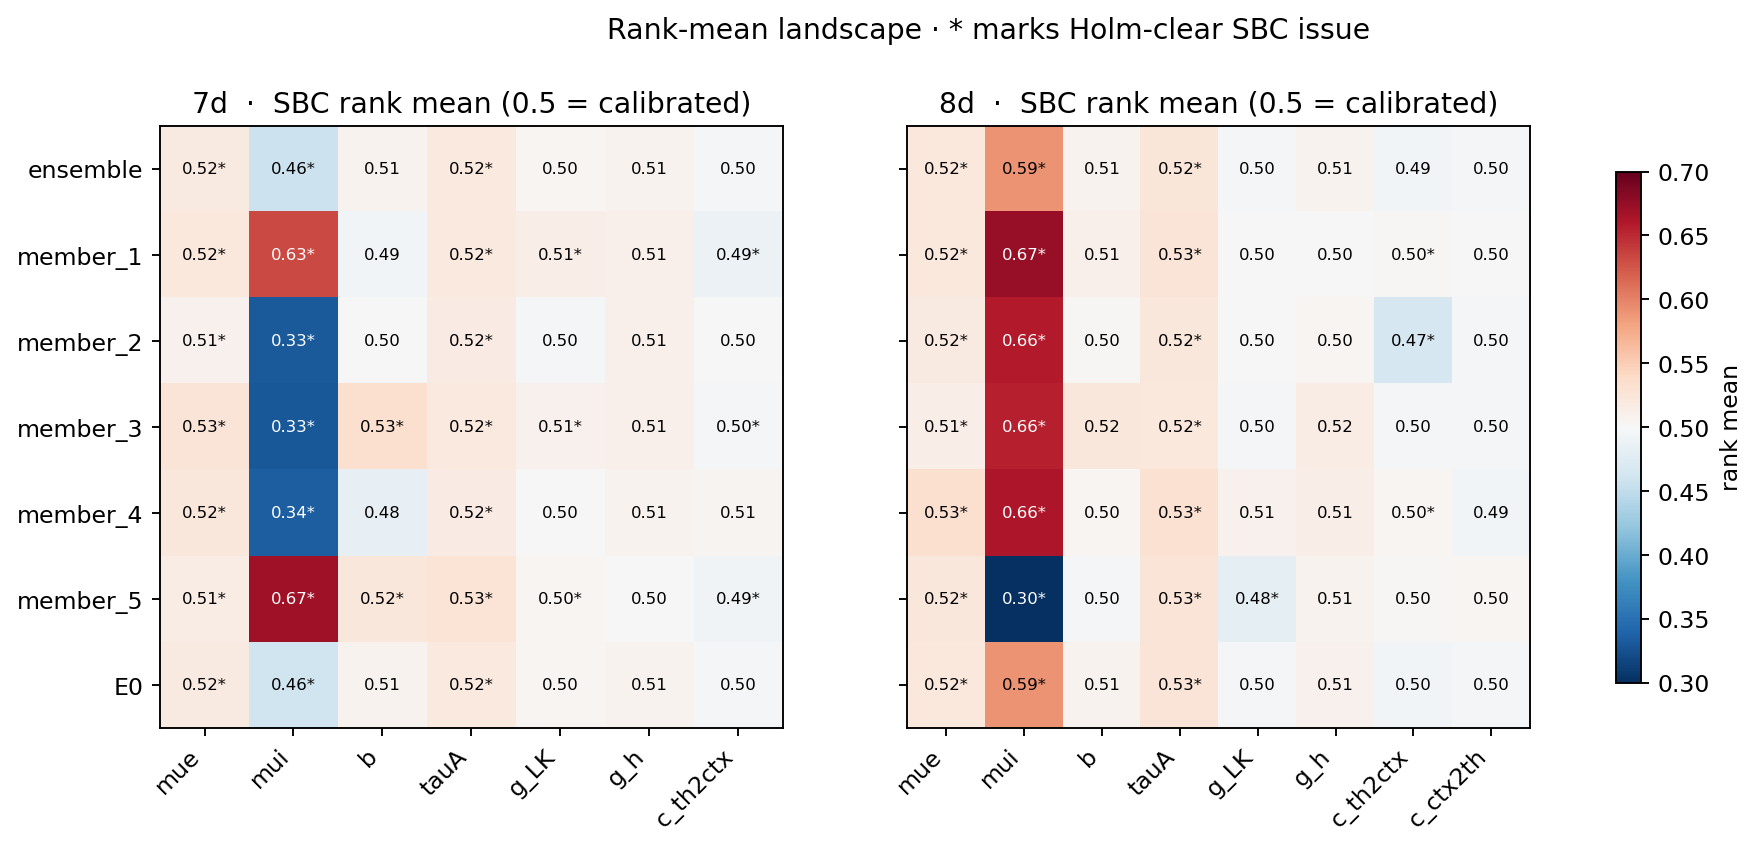

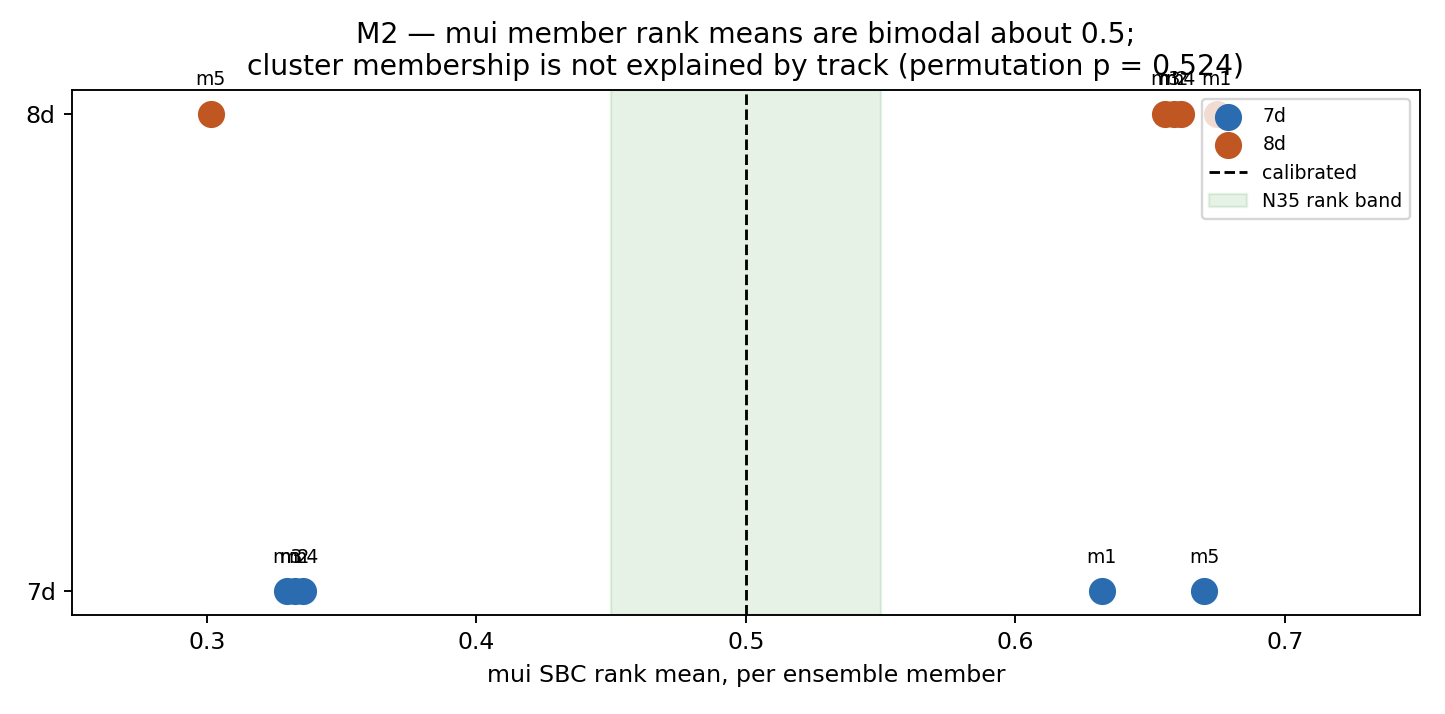

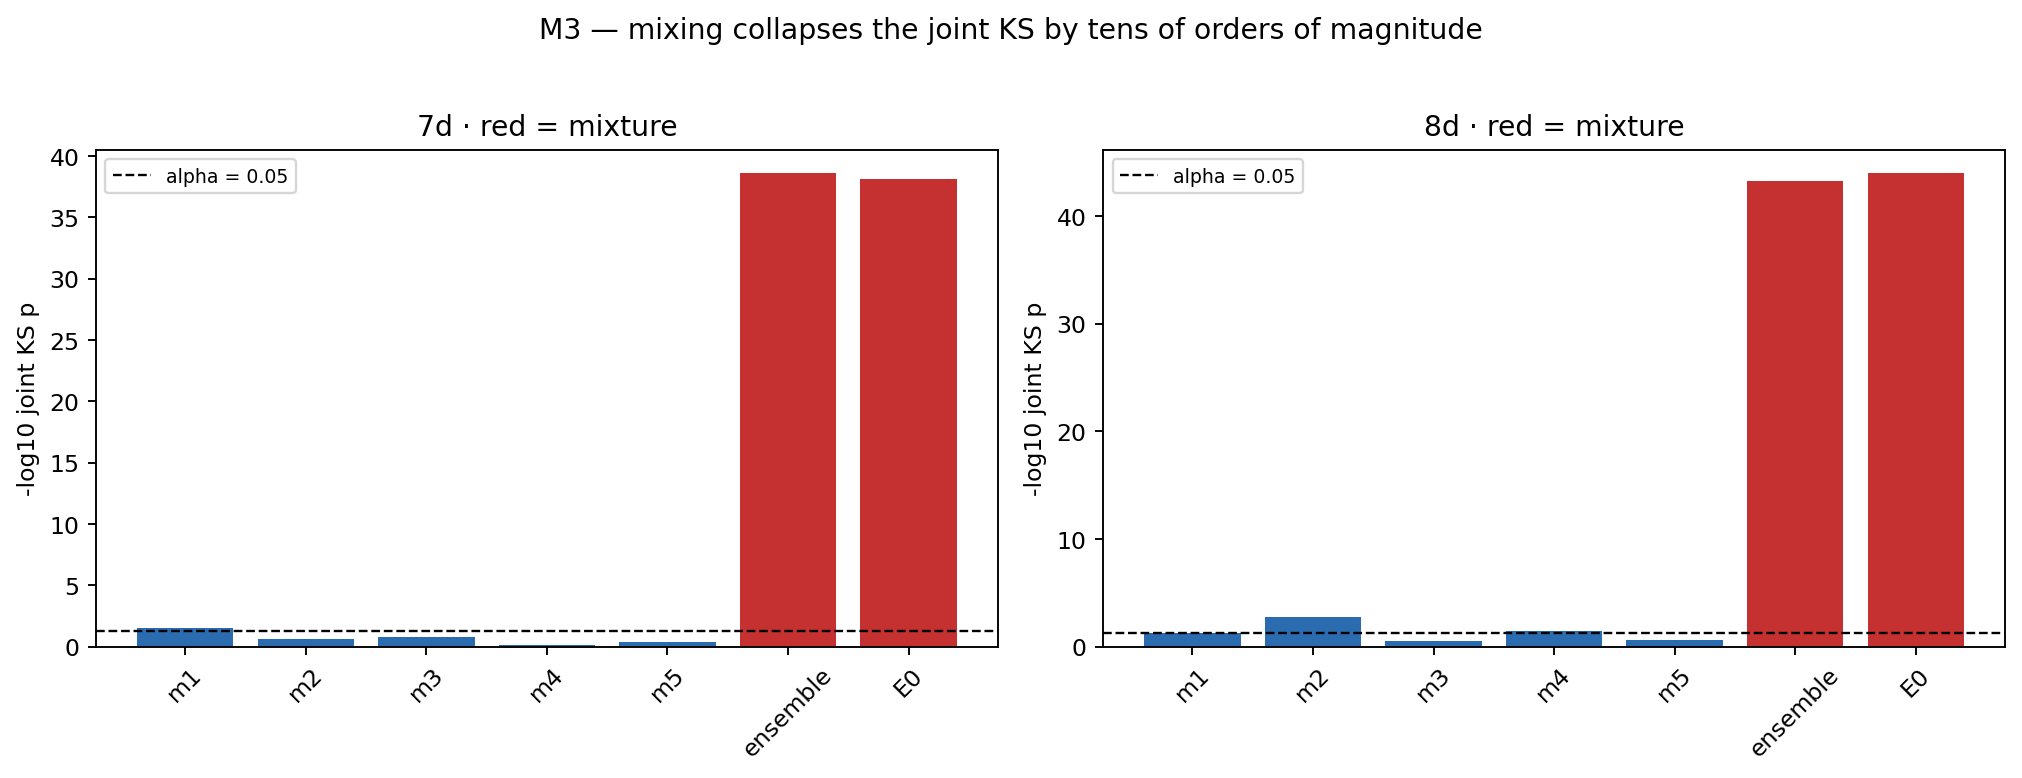

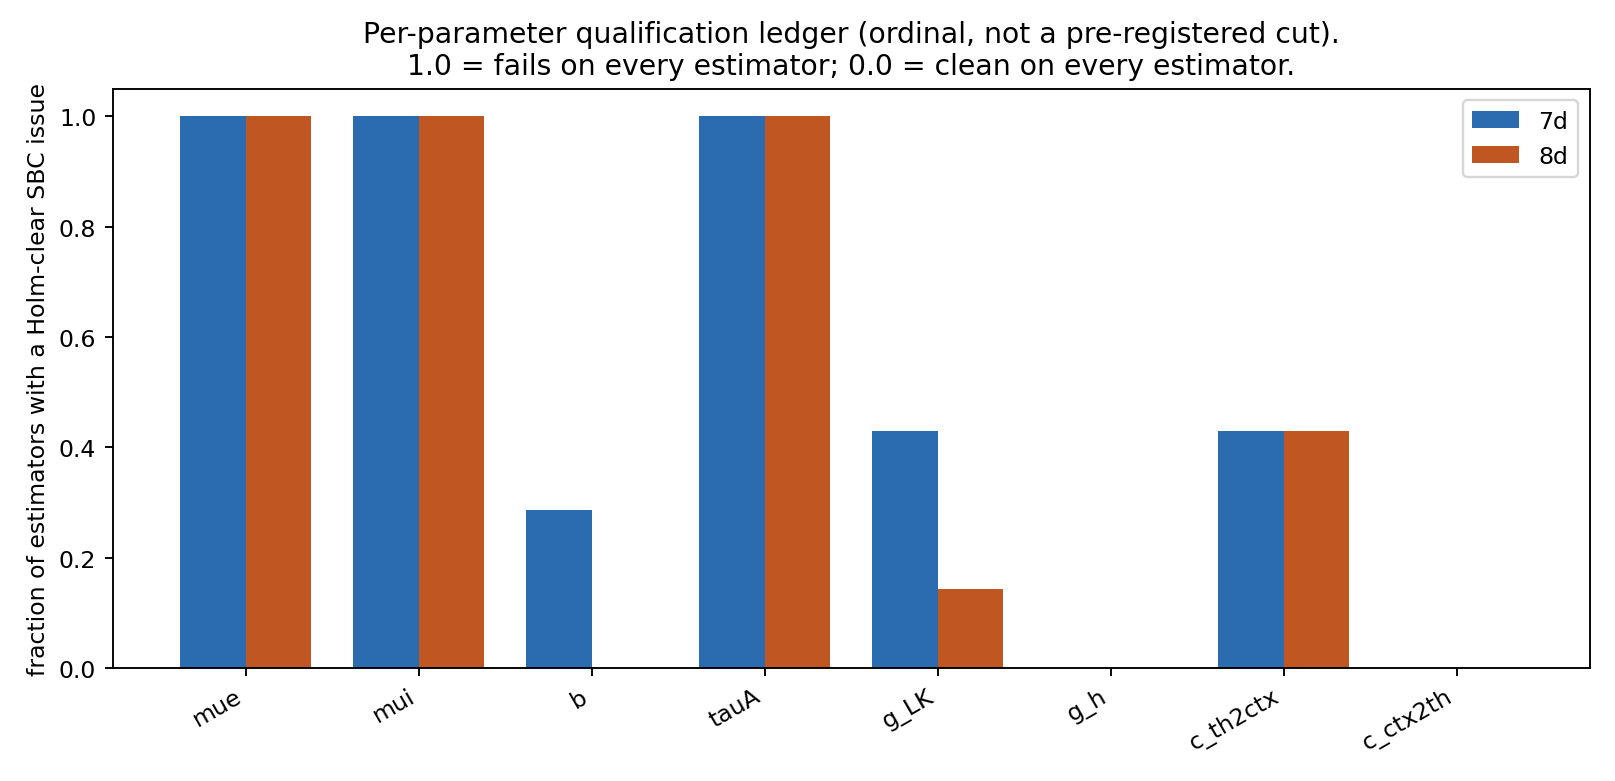

In [24]:
from IPython.display import Image, display as _display

for name in ("fig1_rank_mean_landscape.png", "fig2_mui_bimodality.png",
             "fig3_mixing_amplification.png", "fig4_qualification_ledger.png"):
    path = nb38.SUBDIRS["figures"] / name
    if path.is_file():
        _display(Image(filename=str(path)))

In [25]:
inventory = pd.read_csv(nb38.SUBDIRS["csv"] / "artifact_hash_inventory.csv")
print(f"{len(inventory)} artifacts under "
      f"{nb38.N38_ROOT.relative_to(PROJECT_ROOT).as_posix()}")
print(f"total bytes: {inventory['bytes'].sum():,}")
inventory.head(30)

32 artifacts under S4_sbi/results/figure10_8d_7d/artifacts/notebook_38_claude
total bytes: 491,511


,path,bytes,sha256
0,S4_sbi/results/figure10_8d_7d/artifacts/notebo...,3003,0d5757a160d68071b4d2f4d266c0d788a444ecec4b9ebc...
1,S4_sbi/results/figure10_8d_7d/artifacts/notebo...,5164,51f2f4923f88c0bcff829f74aa4937228abe8def8593c5...
2,S4_sbi/results/figure10_8d_7d/artifacts/notebo...,4564,f34b76d6c145aae6ad0ed90dc98bc4d393c4560998bd01...
3,S4_sbi/results/figure10_8d_7d/artifacts/notebo...,9446,5bbdedb6249461d8f8a04cbe9456c3dd3a0eb9819a571e...
4,S4_sbi/results/figure10_8d_7d/artifacts/notebo...,338,2628387ea5bd9ef83ee52eed5bef36c04c7af60e9d6964...
5,S4_sbi/results/figure10_8d_7d/artifacts/notebo...,349,8453ec7722cbfca66227caff7e4d52944015f676e91c7a...
6,S4_sbi/results/figure10_8d_7d/artifacts/notebo...,16237,e3e1622a83e84dd2594f0364eca45ecc096f16011884f7...
7,S4_sbi/results/figure10_8d_7d/artifacts/notebo...,3402,41dcd73d043adfde43425aa7ef732497c15e3ee556f266...
8,S4_sbi/results/figure10_8d_7d/artifacts/notebo...,154130,f8f9eaf9af866e466a1bdcb8ee65a4c9b80386371afa69...
9,S4_sbi/results/figure10_8d_7d/artifacts/notebo...,59572,385113e6a4e745892141d9357d3ceeb78446c7cbc14000...


---

## What this notebook established

1. **The Development verdict was already on disk.** `S_fail` on 14 of 14 estimator × track cells,
   recomputed from Notebook 36's persisted ranks in seconds and checked statistic-by-statistic
   against its published CSVs. A battery that re-samples to produce this number is not measuring
   anything new — which is why the only new compute here is a 2 × 128-case liveness audit.

2. **E2_ref's Development joint KS is inadmissible, and the repair changes the reading.** It is
   `argmax` over five members on the very dataset it would be tested on. Under a dependence-
   preserving max-of-K null the 7D value falls from 0.712 to 0.289, and the 8D value falls below
   0.05. Disclosure alone would have left a gate with no power to reject.

3. **Pre-registration over already-seen data is nominal.** Every threshold used here is inherited
   verbatim from NB33/34/35/36 rather than chosen now, and coverage@90 — proposed elsewhere as a
   new gate atom — is demoted to description for exactly this reason.

4. **There are two defects, not one.** `mui` shows seed-selected mode collapse (member rank means
   bimodal at ≈ 0.33 / 0.66, symmetric about 0.5, unexplained by track); `mue` and `tauA` show a
   small uniform shift with under-nominal coverage. Mixing amplifies the first, which *derives*
   Notebook 36's `MIXING_ITSELF_IS_THE_DEFECT` rather than restating it. They need different
   repairs.

5. **Something survives.** `g_h` — and `c_ctx2th` on 8D — carry a Holm-clear SBC issue on *no*
   estimator on either track. A monolithic gate would have discarded them along with `mui`.

6. **The sealed bank is preserved by decision, not by accident**, with a pre-registered reopening
   condition, and its never-before-executed battery has now been dry-run end to end.

**The honest limit.** Nothing here establishes *why* `mui`'s likelihood is multimodal, and M5's
prior-anchoring association (Fisher p = 0.14 on 7 parameters, with `b` as a direct counterexample)
is hypothesis-generating only. Neither licenses re-anchoring or narrowing the prior. Route B and
the synthetic-cortical-rate scope are unchanged; closure remains inside Notebook 41.